# 🤖 Reconocimiento de dígitos con Redes Neuronales

## 1. Carga y exploración del dataset

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)
Pixel mínimo: 0
Pixel máximo: 255


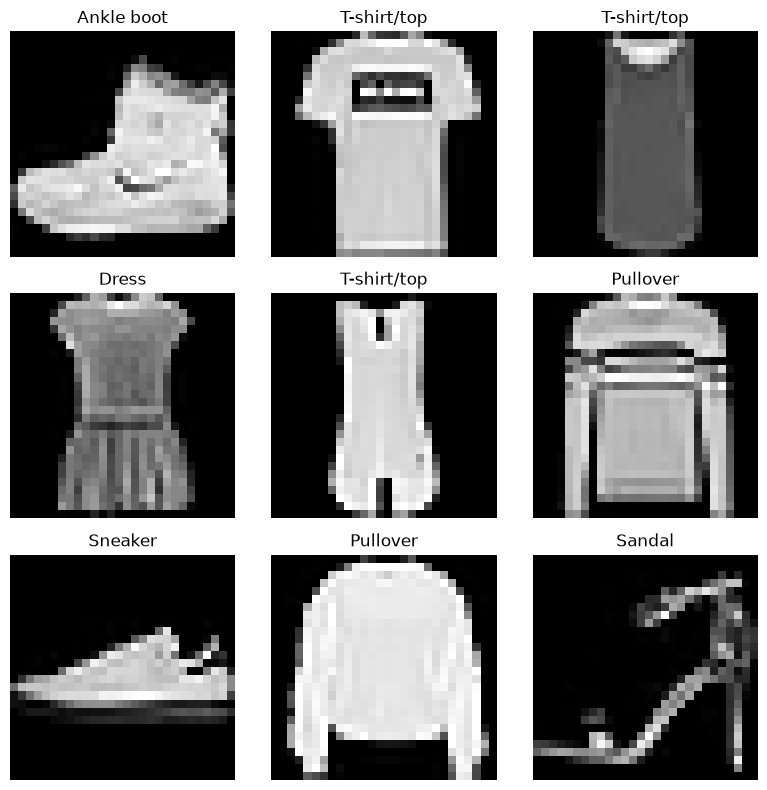

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#MNIST opr default ya esta dividido en train y test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Pixel mínimo:", X_train.min())
print("Pixel máximo:", X_train.max())

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

---

## 2. Preprocesamiento


In [2]:
#Normalizamos los pixeles para trabajar en una escala más controlada
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Mínimo:", X_train.min())
print("Máximo:", X_train.max())

Mínimo: 0.0
Máximo: 1.0


___

## 3. Arquitectura
### Entrada
Procesamos la entrada con **Flatten** ya que sin este cada entrada es una matriz de 28 filas y 28 columnas. Las capas trabajan con listas de valores.
### Primera capa.
La primera capa definimos 128 neuronas como hiperparámetro siendo una forma razonable de comenzar este problema. Aqui aplicaremos las funciones de activación **ReLU y Sigmod** estas funciones procesan los números convierten para que la red aprenda patrones

### Segunda capa.
Tenemos 10 neuronas ya que esperamos 10 predicciónes con diferentes valores y softmax nos ayuda a verlos como probabilidades así de los 10 de cada predicción sabremos cual es la probabilidad más alta del número.

In [3]:
#Estructura de la RED
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    #Capa de activación
    tf.keras.layers.Dense(128, activation="relu"),
    #Capa calculo de probabilidad de la predicción
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Aprendizaje del modelo
- Aqui definimos el optimizador a ser usado. Para corregir los pesos.
- Como calcular el loss.
- Mostrar métricas de imagenes clasificadas correctamente.

In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Entrenamiento base.
- Queremos que repita el dataset de entrenamiento un total de 10 veces.
- Por cada bacht analizará 32 imagenes.
- Apartamos 20% de entrenamiento para validación mientras se desarrolla el modelo y tomar decisiones.

In [5]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8198 - loss: 0.5207 - val_accuracy: 0.8413 - val_loss: 0.4476
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8622 - loss: 0.3848 - val_accuracy: 0.8664 - val_loss: 0.3674
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8724 - loss: 0.3467 - val_accuracy: 0.8719 - val_loss: 0.3552
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - accuracy: 0.8813 - loss: 0.3203 - val_accuracy: 0.8717 - val_loss: 0.3504
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - accuracy: 0.8884 - loss: 0.3015 - val_accuracy: 0.8718 - val_loss: 0.3540
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 984us/step - accuracy: 0.8947 - loss: 0.2875 - val_accuracy: 0.8811 - val_loss: 0.3299
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 918us/step - accuracy: 0.8981 - loss: 0.2745 - val_accuracy: 0.8842 - val_loss: 0.3288
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.9035 - l

In [22]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 580us/step - accuracy: 0.8826 - loss: 0.3440
Test Loss: 0.34403976798057556
Test Accuracy: 0.8826000094413757


___

# 4. Experimentos.

In [7]:
# Función para experimentos 
def build_model(activation="relu", optimizer="sgd"):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation=activation),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#### ReLU + SGD

In [14]:
#ReLU + SGD
model_relu_sgd = build_model("relu", "sgd")
print("ReLU + SGD")
history_relu_sgd = model_relu_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - accuracy: 0.7425 - loss: 0.8103 - val_accuracy: 0.8091 - val_loss: 0.5730
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.8190 - loss: 0.5362 - val_accuracy: 0.8206 - val_loss: 0.5160
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step - accuracy: 0.8342 - loss: 0.4854 - val_accuracy: 0.8298 - val_loss: 0.4874
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 803us/step - accuracy: 0.8423 - loss: 0.4579 - val_accuracy: 0.8406 - val_loss: 0.4535
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 807us/step - accuracy: 0.8485 - loss: 0.4386 - val_accuracy: 0.8467 - val_loss: 0.4398
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step - accuracy: 0.8527 - loss: 0.4249 - val_accuracy: 0.8518 - val_loss: 0.4265
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.8576 - loss: 0.4124 - val_accuracy: 0.8503 - val_loss: 0.4254
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 813us/step - accurac

#### Sigmoid + SGD

In [15]:
#Sigmoid + SGD
model_sigmoid_sgd = build_model("sigmoid", "sgd")
print("Sigmoid + SGD")
history_sigmoid_sgd = model_sigmoid_sgd.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + SGD
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 893us/step - accuracy: 0.6590 - loss: 1.3374 - val_accuracy: 0.7364 - val_loss: 0.9226
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.7468 - loss: 0.8184 - val_accuracy: 0.7613 - val_loss: 0.7307
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - accuracy: 0.7670 - loss: 0.6951 - val_accuracy: 0.7733 - val_loss: 0.6517
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - accuracy: 0.7832 - loss: 0.6338 - val_accuracy: 0.7850 - val_loss: 0.6094
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - accuracy: 0.7943 - loss: 0.5943 - val_accuracy: 0.7972 - val_loss: 0.5774
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - accuracy: 0.8042 - loss: 0.5661 - val_accuracy: 0.8048 - val_loss: 0.5545
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 818us/step - accuracy: 0.8115 - loss: 0.5446 - val_accuracy: 0.8134 - val_loss: 0.5367
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - accu

#### ReLU + Adam

In [16]:
#ReLU + Adam
model_relu_adam = build_model("relu", "adam")
print("ReLU + Adam")
history_relu_adam = model_relu_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

ReLU + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8165 - loss: 0.5211 - val_accuracy: 0.8478 - val_loss: 0.4223
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 965us/step - accuracy: 0.8629 - loss: 0.3867 - val_accuracy: 0.8641 - val_loss: 0.3766
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - accuracy: 0.8733 - loss: 0.3467 - val_accuracy: 0.8695 - val_loss: 0.3609
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.8838 - loss: 0.3194 - val_accuracy: 0.8714 - val_loss: 0.3524
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 968us/step - accuracy: 0.8891 - loss: 0.3016 - val_accuracy: 0.8792 - val_loss: 0.3363
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8950 - loss: 0.2871 - val_accuracy: 0.8845 - val_loss: 0.3200
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.8983 - loss: 0.2740 - val_accuracy: 0.8792 - val_loss: 0.3348
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - accuracy: 

#### Sigmoid + Adam

In [17]:
#Sigmoid + Adam
model_sigmoid_adam = build_model("sigmoid", "adam")
print("Sigmoid + Adam")
history_sigmoid_adam = model_sigmoid_adam.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Sigmoid + Adam
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8092 - loss: 0.5659 - val_accuracy: 0.8455 - val_loss: 0.4318
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8555 - loss: 0.4043 - val_accuracy: 0.8534 - val_loss: 0.4013
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step - accuracy: 0.8685 - loss: 0.3670 - val_accuracy: 0.8685 - val_loss: 0.3636
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 993us/step - accuracy: 0.8778 - loss: 0.3407 - val_accuracy: 0.8734 - val_loss: 0.3450
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8834 - loss: 0.3238 - val_accuracy: 0.8795 - val_loss: 0.3349
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8887 - loss: 0.3064 - val_accuracy: 0.8738 - val_loss: 0.3481
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8940 - loss: 0.2930 - val_accuracy: 0.8845 - val_loss: 0.3196
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.896

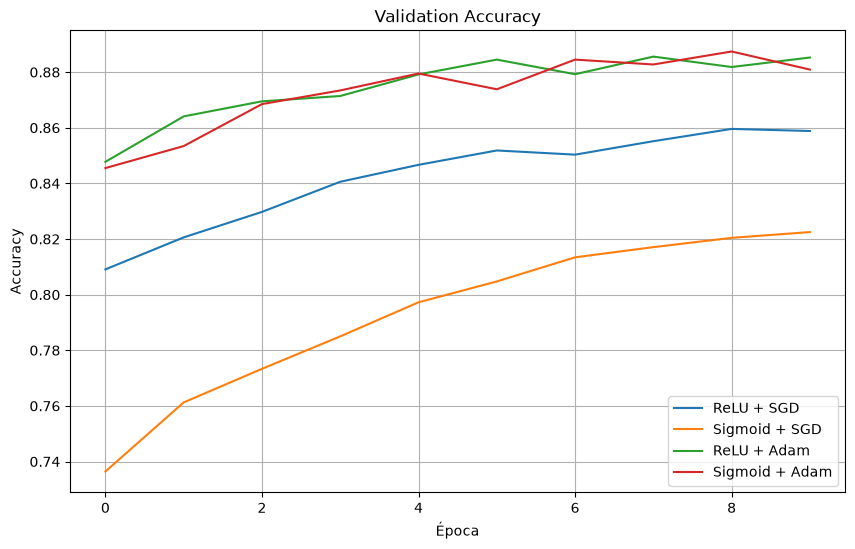

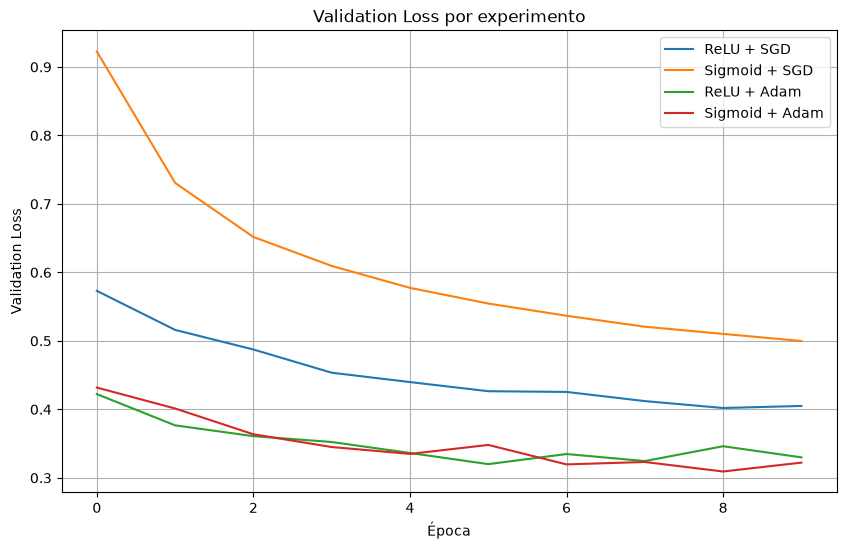

In [23]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_accuracy"], label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_accuracy"], label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_accuracy"], label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_accuracy"], label="Sigmoid + Adam")

plt.title("Validation Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_relu_sgd.history["val_loss"],label="ReLU + SGD")
plt.plot(history_sigmoid_sgd.history["val_loss"],label="Sigmoid + SGD")
plt.plot(history_relu_adam.history["val_loss"],label="ReLU + Adam")
plt.plot(history_sigmoid_adam.history["val_loss"],label="Sigmoid + Adam")

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Validation Loss por experimento")
plt.legend()
plt.grid(True)
plt.show()



___

# 5. Evaluación


### Para continuar, vamos a utilizar ReLU + Adam, porque en nuestros experimentos fue la configuración que obtuvo la mayor accuracy de validación al finalizar las 10 épocas: 88.52% en entrenamiento.

In [24]:
model_final = build_model("relu", "adam")
history_final = model_final.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8225 - loss: 0.5108 - val_accuracy: 0.8415 - val_loss: 0.4294
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 921us/step - accuracy: 0.8609 - loss: 0.3846 - val_accuracy: 0.8701 - val_loss: 0.3626
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - accuracy: 0.8755 - loss: 0.3437 - val_accuracy: 0.8738 - val_loss: 0.3505
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accuracy: 0.8842 - loss: 0.3196 - val_accuracy: 0.8849 - val_loss: 0.3307
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.8896 - loss: 0.3004 - val_accuracy: 0.8813 - val_loss: 0.3379
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 960us/step - accuracy: 0.8941 - loss: 0.2872 - val_accuracy: 0.8817 - val_loss: 0.3265
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.8989 - loss: 0.2735 - val_accuracy: 0.8803 - val_loss: 0.3261
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 933us/step - accuracy: 0.9028 - l

In [20]:
test_loss, test_accuracy = model_final.evaluate(
    X_test,
    y_test
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - accuracy: 0.8767 - loss: 0.3572
Test loss: 0.3572391867637634
Test accuracy: 0.8766999840736389


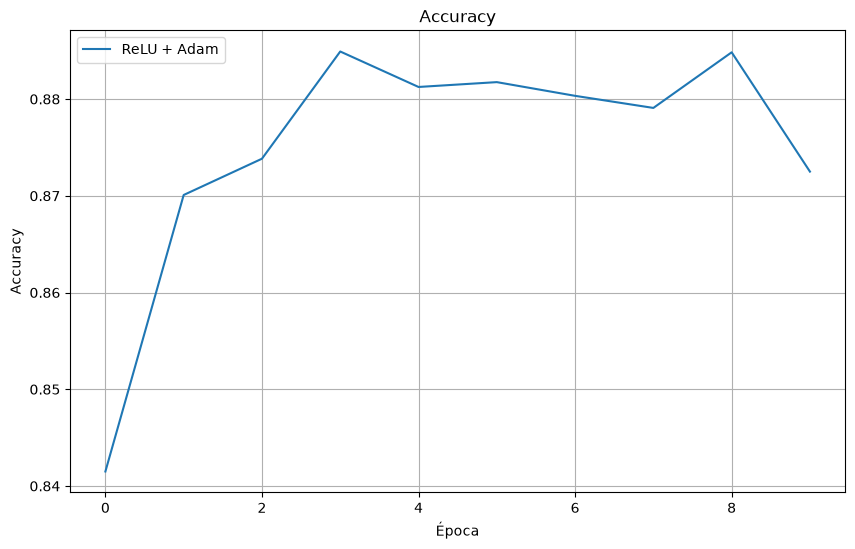

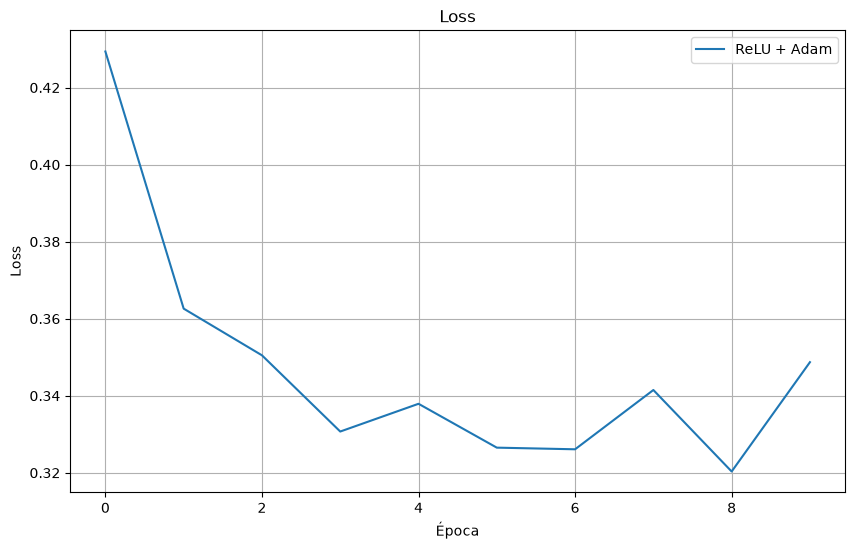

In [25]:
#Grafica Accuracy

plt.figure(figsize=(10, 6))

plt.plot(history_final.history["val_accuracy"], label="ReLU + Adam")

plt.title("Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#Grafica Loss
plt.figure(figsize=(10, 6))

plt.plot(history_final.history["val_loss"],label="ReLU + Adam")

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Aproximadamente 8.767 imágenes fueron clasificadas correctamente y unas 1174 fueron clasificadas incorrectamente.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step


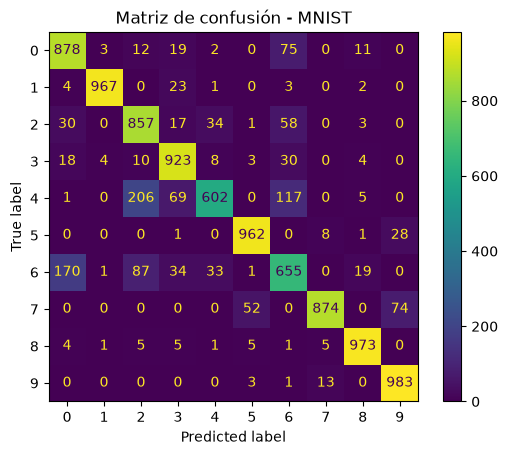

In [26]:
y_pred_prob = model_final.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)



cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot()
plt.title("Matriz de confusión - MNIST")
plt.show()

## Mi modelo tiene 87.67%, pero todavía confunde determinadas formas de prendas, y aquí podemos observar un ejemplo concreto.

Cantidad de errores: 1326
Índice de la imagen: 1374
Etiqueta real: 2
Predicción: 4


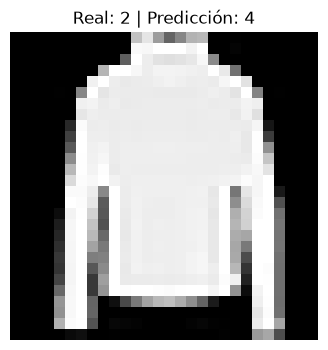

Probabilidades(que tan seguro estaba el modelo):
0: 0.0000
1: 0.0000
2: 0.3966
3: 0.0001
4: 0.4433
5: 0.0000
6: 0.1599
7: 0.0000
8: 0.0000
9: 0.0000


In [27]:
import random
incorrectos = np.where(y_test != y_pred)[0]

print("Cantidad de errores:", len(incorrectos))

aleatorio = random.randint(1,len(incorrectos))
i = incorrectos[aleatorio]

print("Índice de la imagen:", i)
print("Etiqueta real:", y_test[i])
print("Predicción:", y_pred[i])

plt.figure(figsize=(4, 4))
plt.imshow(X_test[i], cmap="gray")
plt.title(
    f"Real: {y_test[i]} | Predicción: {y_pred[i]}"
)

plt.axis("off")
plt.show()


print("Probabilidades(que tan seguro estaba el modelo):")
for clase, probabilidad in enumerate(y_pred_prob[i]):
    print(f"{clase}: {probabilidad:.4f}")

# 6. Conclusiones